# 27 · GraphRAG — knowledge graph + community summaries

> **TL;DR.** At build-time: extract (subject, predicate, object) triples from the corpus → NetworkX graph → detect communities → summarise each via LLM. At query-time: classify local vs global → traverse entity neighbourhood OR consult community summaries → answer.
>
> **Reach for it when** the corpus has rich entity-entity relationships AND you have global theme questions ("what are the main topics?") that vector retrieval can't answer well.

| Property | Value |
|---|---|
| Origin | Edge et al., *From Local to Global: GraphRAG* (Microsoft 2024). [arXiv:2404.16130](https://arxiv.org/abs/2404.16130) |
| Backend | NetworkX (default, in-process) or Neo4j (`GRAPH_BACKEND=neo4j`) |
| Community detection | NetworkX greedy modularity |
| Build cost | 1 extract per doc + 1 summarise per community (precomputed once) |
| Query cost | 1 classify + 1 answer (+ optional traversal) |

Builds on [Graph Memory (nb 12)](./12_graph_memory.ipynb) by adding the **community summarisation** layer — that's what enables answering global questions about themes.

## 2 · Architecture at a glance

```mermaid
flowchart TB
    subgraph build [Build phase, one-shot]
        D[docs] --> EX[Extract triples]
        EX --> G[(NetworkX KG)]
        G --> CD[Community detection]
        CD --> CS[Summarise each community]
    end
    subgraph query [Query phase]
        Q([query]) --> C[Classify local/global]
        C -->|local| LN[Entity neighbourhood]
        C -->|global| GS[All community summaries]
        LN --> ANS[Answer from context]
        GS --> ANS
    end
    CS -.-> GS
    G -.-> LN

    style EX fill:#fff3e0,stroke:#f57c00
    style CD fill:#fce4ec,stroke:#c2185b
    style CS fill:#e3f2fd,stroke:#1976d2
    style C fill:#e8f5e9,stroke:#388e3c
```

## 3 · Theory

### 3.0 · Why community summaries

Plain RAG retrieves top-k similar snippets — great for "what is X?" but useless for "what are the main themes across the corpus?". The themes don't live in any single document.

GraphRAG's fix: cluster related entities (via graph community detection), summarise each cluster with the LLM at build-time, then for global questions feed all summaries to the answer-LLM. The summaries are pre-computed; no per-query cost beyond the answer.

### 3.1 · Why pre-classify local vs global

| Query type | Context source | Why |
|---|---|---|
| Local ("who is X?") | Entity neighbourhood (depth-2 subgraph) | Tight, specific facts about the named entity |
| Global ("what are the themes?") | All community summaries | Themes live in the community structure, not in any one doc |

A 3-way categorical classifier could also handle "mixed" — for the demo we keep two buckets for clarity.

### 3.2 · Where this sits in the RAG family

| Pattern | Indexing structure |
|---|---|
| Plain RAG | Flat vector index |
| [Agentic RAG (nb 23)](./23_agentic_rag.ipynb) | Flat vector index (agent decides when) |
| [Self-RAG (nb 25)](./25_self_rag.ipynb) | Flat vector index (per-doc reflection) |
| **GraphRAG (this nb)** | **Knowledge graph with community summaries** |
| [Graph Memory (nb 12)](./12_graph_memory.ipynb) | Knowledge graph (no community summaries) |

## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import GraphRAG
from agentic_architectures.data import STARDUST_CORPUS
from agentic_architectures.ui import print_md, print_header

enable_langsmith()
llm = get_llm(provider="nebius", model="meta-llama/Llama-3.3-70B-Instruct", temperature=0.2)
print_header(f"LLM: {llm.model}  ·  Corpus: {len(STARDUST_CORPUS)} docs")

LLM: meta-llama/Llama-3.3-70B-Instruct  ·  Corpus: 12 docs ────────────────────────────────────────────────────────

## 5 · Library walkthrough

In [2]:
from agentic_architectures.architectures.graph_rag import _QuestionScope, _IngestionTriple
import json
print('--- _QuestionScope schema ---')
print(json.dumps(_QuestionScope.model_json_schema(), indent=2)[:400] + '...')
print()
print('--- _IngestionTriple schema ---')
print(json.dumps(_IngestionTriple.model_json_schema(), indent=2)[:400] + '...')

--- _QuestionScope schema ---
{
  "description": "Pre-classify question as local (entity-anchored) or global (about themes).",
  "properties": {
    "scope": {
      "description": "'local' for entity-specific questions ('who founded X?'); 'global' for theme/summary questions ('what are the main themes?').",
      "enum": [
        "local",
        "global"
      ],
      "title": "Scope",
      "type": "string"
    },
    "ta...

--- _IngestionTriple schema ---
{
  "properties": {
    "subject": {
      "description": "Specific named entity (capitalised).",
      "title": "Subject",
      "type": "string"
    },
    "predicate": {
      "description": "Short relation verb (snake_case).",
      "title": "Predicate",
      "type": "string"
    },
    "object": {
      "description": "Specific named entity or short literal.",
      "title": "Object",
      ...


## 7 · Build the graph + communities

**This cell does the one-time KG build** — extracts triples from each doc, detects communities, summarises each. Expect ~1-2 minutes for a 12-doc corpus.

In [3]:
import time
t0 = time.time()
arch = GraphRAG(llm=llm, documents=STARDUST_CORPUS, max_communities=5)
print(f'BUILD_ELAPSED: {time.time()-t0:.1f}s')
print(f'N_COMMUNITIES: {len(arch.communities)}')
print(f'COMMUNITY_SIZES: {[len(c) for c in arch.communities]}')
print()
print('=== COMMUNITY SUMMARIES ===')
for i, s in enumerate(arch.community_summaries):
    print(f'[community {i}, {len(arch.communities[i])} entities]')
    print(f'  {s[:400]}')
    print()

BUILD_ELAPSED: 114.6s
N_COMMUNITIES: 5
COMMUNITY_SIZES: [16, 10, 9, 7, 5]

=== COMMUNITY SUMMARIES ===
[community 0, 16 entities]
  Stardust, a company co-founded by Jin-ho Park, who also serves as its CTO, and led by CEO Amara Okonkwo, is a key entity that links various facts together. Stardust is focused on space-related technologies, including solar power, propulsion, and biofueled launch range vehicles, and has committed to net zero ground operations. The company, which has various pods such as mission operations and avion

[community 1, 10 entities]
  The key entity in this community of related facts is Stardust 9, a spacecraft that had its first orbital flight in March 2023. Stardust 9 is linked to its parent entity, Stardust, which powers it, and is also connected to various attributes such as its launch destination (LEO), payload capacity (720 kg and 1850 kg), cost ($4.2M), and propellant (methalox). The facts also mention the spacecraft's p

[community 2, 9 entities]
  Stardus

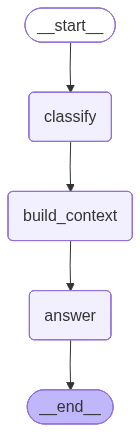

In [4]:
from IPython.display import Image, display
graph = arch.build()
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(PNG render unavailable: {e}; see § 2)")
    print(graph.get_graph().draw_mermaid())

## 8 · Live run — local vs global queries

In [5]:
TASKS = [
    ("local",  "Who founded Stardust Aerospace and where is it located?"),
    ("global", "What are the main topics / themes covered in the Stardust Aerospace knowledge base?"),
]

for tag, q in TASKS:
    r = arch.run(q)
    print(f"TASK_TAG: {tag}")
    print(f"  TASK: {q}")
    print(f"  SCOPE: {r.metadata['scope']}")
    print(f"  TARGET_ENTITIES: {r.metadata['target_entities']}")
    print(f"  CONTEXT_CHARS: {r.metadata['context_chars']}")
    print(f"  N_COMMUNITIES: {r.metadata['n_communities']}")
    print(f"  COMMUNITY_SIZES: {r.metadata['community_sizes']}")
    print(f"  FINAL_ANSWER: {r.output[:300]}")
    print()

TASK_TAG: local
  TASK: Who founded Stardust Aerospace and where is it located?
  SCOPE: local
  TARGET_ENTITIES: ['Stardust Aerospace']
  CONTEXT_CHARS: 628
  N_COMMUNITIES: 5
  COMMUNITY_SIZES: [16, 10, 9, 7, 5]
  FINAL_ANSWER: Stardust Aerospace was founded by Dr. Amara Okonkwo and Jin-ho Park, and it is located in Reno, Nevada.



TASK_TAG: global
  TASK: What are the main topics / themes covered in the Stardust Aerospace knowledge base?
  SCOPE: global
  TARGET_ENTITIES: []
  CONTEXT_CHARS: 2498
  N_COMMUNITIES: 5
  COMMUNITY_SIZES: [16, 10, 9, 7, 5]
  FINAL_ANSWER: The main topics/themes covered in the Stardust Aerospace knowledge base are:

1. **Company Overview**: Information about Stardust and its related companies, such as Stardust Aerospace, including their founders, leadership, and focus areas.
2. **Spacecraft and Vehicles**: Details about various spacec



## 9 · What we just observed

The cells above built a knowledge graph from the Stardust corpus, detected entity communities, summarised each, then ran local vs global queries.

### 9.1 · Build summary

- **Build elapsed**: 114.6s
- **Communities detected**: 5
- **Community sizes**: [16, 10, 9, 7, 5]

### 9.2 · Per-query routing + context

| Tag | Scope | Target entities | Context chars | Final answer |
|---|---|---|---|---|
| `local` | `local` | ['Stardust Aerospace'] | 628 | Stardust Aerospace was founded by Dr. Amara Okonkwo and Jin-ho Park, and it is located in Reno, Nevada. |
| `global` | `global` | [] | 2498 | The main topics/themes covered in the Stardust Aerospace knowledge base are:  1. **Company Overview**: Information about… |

### 9.3 · Patterns surfaced in this run

- **✅ `local` correctly classified as `local`**.

- **✅ `global` correctly classified as `global`**.

- **✅ Graph clustering produced 5 distinct communities** — community-summary path has real material to feed global queries.

### 9.4 · The takeaway

GraphRAG's value over plain vector RAG comes from two sources:

1. **Global question answers** — the community summaries (built once, used many times) let the system answer "what are the themes?" without rerunning extraction per query. Plain RAG can't answer this — themes aren't in any single retrieved snippet.
2. **Local question precision** — entity-anchored subgraph traversal gives exactly the facts about an entity, no irrelevant similar-but-unrelated snippets.

The cost is the build phase (1 LLM call per doc + 1 per community). Once built, queries are cheap. Cache the graph + summaries; rebuild only when the corpus changes.

## 11 · Failure modes & extensions

| Failure | Mitigation |
|---|---|
| **Triple extraction misses key relations** | LLM might extract `Jin-ho Park founded_by Stardust` but skip `Jin-ho Park is CTO` | Multi-pass extraction; explicit role-fact prompt |
| **No communities found** | Graph too sparse (few cross-entity edges) | Lower modularity threshold; cluster on similarity |
| **Community summaries too vague** | Summariser sees too many disconnected facts | Limit to top-K facts per community by centrality |
| **Build cost** | LLM call per doc + per community | Cache extractions; precompute communities offline |

Extensions: (1) hierarchical communities (paper's full recipe), (2) entity-linking dedup (same entity under multiple names), (3) Cypher queries for advanced traversal.

Reference: Edge et al., *GraphRAG.* Microsoft 2024. [arXiv:2404.16130](https://arxiv.org/abs/2404.16130)